# TP2 — Segmentation RFM & Clustering Hiérarchique | Lumina & Co

**Équipe** : Léopold (distribution achats), Bill/Ash (saisonnalité), Younes (géographie), Kylian (relations variables)  
**Dataset** : Historique CRM e-commerce UK (2007-2011), ~50k clients  
**Objectif** : Répondre à la question du CMO — "Qui sont nos clients ?" — via segmentation RFM et clustering hiérarchique sur features enrichies.

In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

import warnings
warnings.filterwarnings('ignore')

# Configuration graphiques
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Imports OK")

✓ Imports OK


---
## Étape 1 : Chargement des données et data quality report

In [ ]:
df_clean = pd.read_csv('../../data/transaction_clean.csv')

print(f"Données chargées : {df_clean.shape[0]} lignes et {df_clean.shape[1]} colonnes")
print("\n" + "="*80)
print("Aperçu des premières lignes :")
print("="*80)
df_clean.head()

FileNotFoundError: [Errno 2] No such file or directory: 'transaction_clean.csv'

In [ ]:
# Info sur les colonnes et les types de données
print("Informations sur le dataset :")
print("="*80)
df_clean.info()
print("\n" + "="*80)
print("Statistiques descriptives :")
print("="*80)
df_clean.describe()

Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1802615 entries, 0 to 1802614
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   invoice_id       object 
 1   customer_id      float64
 2   product_code     object 
 3   product_name     object 
 4   quantity         float64
 5   unit_price       float64
 6   invoice_date     object 
 7   country          object 
 8   from_store       object 
 9   retour_commande  object 
 10  total_price      float64
dtypes: float64(4), object(7)
memory usage: 151.3+ MB

Statistiques descriptives :


,customer_id,quantity,unit_price,total_price
count,1.392225e+06,1.786429e+06,1.802615e+06,1.786429e+06
mean,2.253993e+04,1.132868e+01,3.868446e+00,2.039547e+01
std,1.262789e+04,1.400710e+02,9.268373e+01,2.313856e+02
min,1.234600e+04,-8.099500e+04,-5.359436e+04,-1.684696e+05
25%,1.491100e+04,1.000000e+00,1.250000e+00,3.750000e+00
50%,1.756100e+04,4.000000e+00,2.100000e+00,1.008000e+01
75%,2.199300e+04,1.200000e+01,3.750000e+00,1.785000e+01
max,6.344100e+04,8.099500e+04,3.897000e+04,1.684696e+05


---
## Étape 1 : Construction des features RFM enrichies

**Date de référence** : date max du dataset + 1 jour (snapshot réaliste, pas la date du jour).

**Features calculées** (7 au total) :

| Feature | Définition | Justification |
|---|---|---|
| Récence | Jours depuis le dernier achat | Indicateur d'engagement récent |
| Fréquence | Nb factures distinctes | Régularité d'achat |
| Montant | Somme des total_price | Valeur totale client |
| Panier Moyen | Montant moyen par commande | Distingue gros paniers ponctuels vs petits paniers fréquents |
| Nb Catégories | product_codes distincts achetés | Diversité du comportement d'achat |
| Tenure | Jours depuis le 1er achat → date ref | Ancienneté ≠ récence (un client ancien peut être inactif) |
| Ratio Promo | % d'achats en sept-nov | Sensibilité aux pics saisonniers identifiés dans l'EDA |

**Décisions** :
- `product_code` sert de proxy pour la catégorie produit (pas de colonne catégorie explicite dans le dataset).
- Le ratio promo est basé sur les mois sept-nov, période de pic de saisonnalité identifié lors de l'EDA (TP1 Étape 3).

In [ ]:
df_clean['invoice_date'] = pd.to_datetime(df_clean['invoice_date'])

print("Période des données :")
print(f"  - Date minimale : {df_clean['invoice_date'].min()}")
print(f"  - Date maximale : {df_clean['invoice_date'].max()}")
print(f"  - Durée : {(df_clean['invoice_date'].max() - df_clean['invoice_date'].min()).days} jours")
print(f"\nNombre de clients uniques : {df_clean['customer_id'].nunique()}")

Période des données :
  - Date minimale : 2007-07-06 12:20:00
  - Date maximale : 2011-12-09 12:50:00
  - Durée : 1617 jours

Nombre de clients uniques : 49146


In [ ]:
# Date de référence = date max du dataset + 1 jour
date_reference = df_clean['invoice_date'].max() + pd.Timedelta(days=1)
print(f"Date de référence pour le calcul RFM : {date_reference.date()}")

# --- Features RFM de base ---
rfm = df_clean.groupby('customer_id').agg(
    Recence=('invoice_date', lambda x: (date_reference - x.max()).days),
    Frequence=('invoice_id', 'nunique'),
    Montant=('total_price', 'sum')
).reset_index()

# --- Features comportementales enrichies ---

# Panier moyen par commande
panier_moyen = (df_clean.groupby(['customer_id', 'invoice_id'])['total_price']
                .sum()
                .groupby('customer_id').mean())
rfm['Panier_Moyen'] = rfm['customer_id'].map(panier_moyen)

# Nombre de catégories produits distinctes (proxy = product_code distinct)
nb_categories = df_clean.groupby('customer_id')['product_code'].nunique()
rfm['Nb_Categories'] = rfm['customer_id'].map(nb_categories)

# Ancienneté (tenure) : jours entre 1er achat et date de référence
tenure = df_clean.groupby('customer_id')['invoice_date'].min().apply(
    lambda x: (date_reference - x).days
)
rfm['Tenure'] = rfm['customer_id'].map(tenure)

# Proportion d'achats en période promotionnelle (proxy : sept-nov = pic saisonnier EDA)
df_clean['is_promo'] = df_clean['invoice_date'].dt.month.isin([9, 10, 11])
promo_ratio = df_clean.groupby('customer_id')['is_promo'].mean()
rfm['Ratio_Promo'] = rfm['customer_id'].map(promo_ratio)

print(f"✓ Features RFM enrichies calculées pour {len(rfm)} clients")
print(f"\nFeatures : {rfm.columns.tolist()}")
print(f"\n{rfm.describe().round(2)}")
rfm.head(10)

Date de référence pour le calcul RFM : 2011-12-10
✓ Features RFM enrichies calculées pour 49146 clients

Features : ['customer_id', 'Recence', 'Frequence', 'Montant', 'Panier_Moyen', 'Nb_Categories', 'Tenure', 'Ratio_Promo']

       customer_id   Recence  Frequence    Montant  Panier_Moyen  \
count     49146.00  49146.00   49146.00   49146.00      49146.00   
mean      37842.67    360.26       4.65     607.38         82.50   
std       14853.29    317.31      10.15    4904.54        217.23   
min       12346.00      1.00       1.00  -25111.09     -25111.09   
25%       24895.25     88.00       1.00      28.20         18.08   
50%       37890.50    270.00       2.00      84.65         37.67   
75%       50752.75    568.00       5.00     327.50         85.08   
max       63441.00   1618.00     510.00  570380.61      11880.84   

       Nb_Categories    Tenure  Ratio_Promo  
count       49146.00  49146.00     49146.00  
mean           21.75    566.13         0.31  
std            54.61   

,customer_id,Recence,Frequence,Montant,Panier_Moyen,Nb_Categories,Tenure,Ratio_Promo
0,12346.0,326,17,-51.74,-3.043529,30,726,0.042553
1,12347.0,2,8,4921.53,615.191250,126,404,0.391892
2,12348.0,75,5,2019.40,403.880000,25,438,0.450980
3,12349.0,19,5,4404.54,880.908000,139,736,0.711111
4,12350.0,310,1,334.40,334.400000,17,310,0.000000
5,12351.0,375,1,300.93,300.930000,21,375,1.000000
6,12352.0,36,13,1889.21,145.323846,70,393,0.575221
7,12353.0,204,2,406.76,203.380000,23,409,0.833333
8,12354.0,232,1,1079.40,1079.400000,58,232,0.000000
9,12355.0,214,2,947.61,473.805000,35,568,0.000000


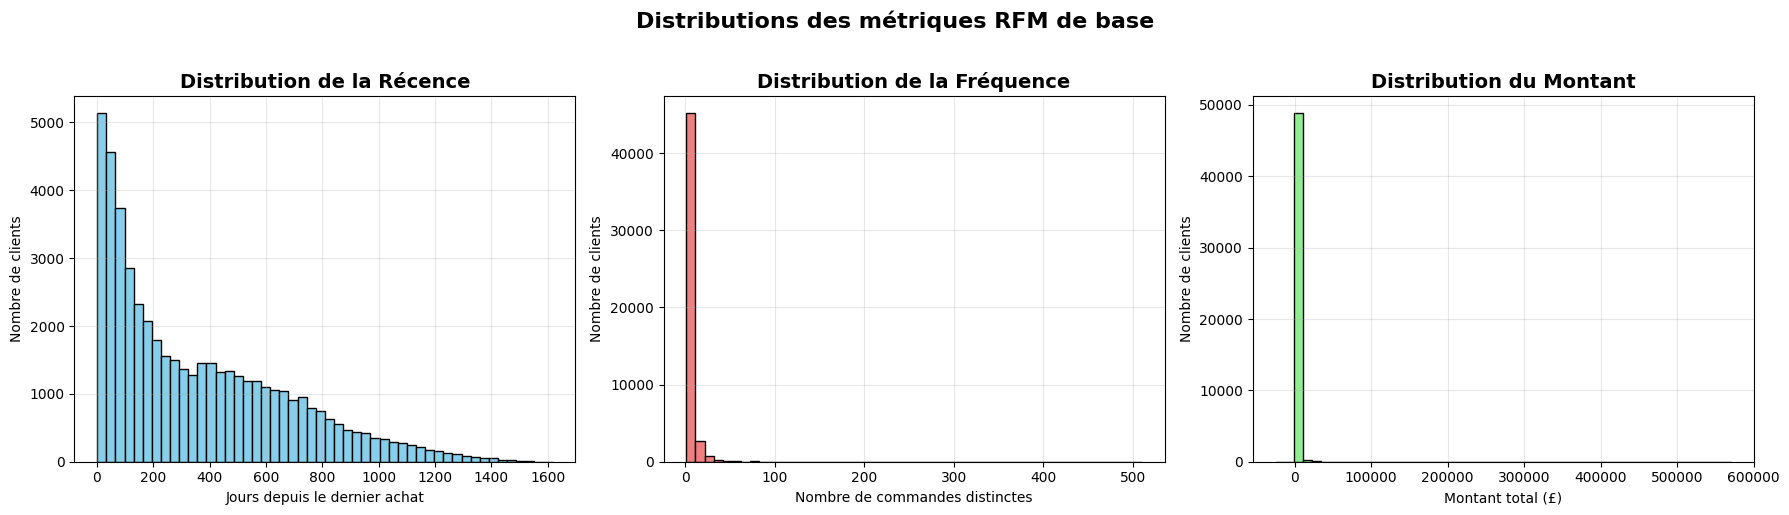

In [ ]:
# Histogrammes des distributions RFM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm['Recence'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Recency distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Number of customers')
axes[0].grid(alpha=0.3)

axes[1].hist(rfm['Frequence'], bins=50, color='lightcoral', edgecolor='black')
axes[1].set_title('Frequency distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of distinct orders')
axes[1].set_ylabel('Number of customers')
axes[1].grid(alpha=0.3)

axes[2].hist(rfm['Montant'], bins=50, color='lightgreen', edgecolor='black')
axes[2].set_title('Monetary distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Total amount (£)')
axes[2].set_ylabel('Number of customers')
axes[2].grid(alpha=0.3)

plt.suptitle('Distributions of core RFM metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

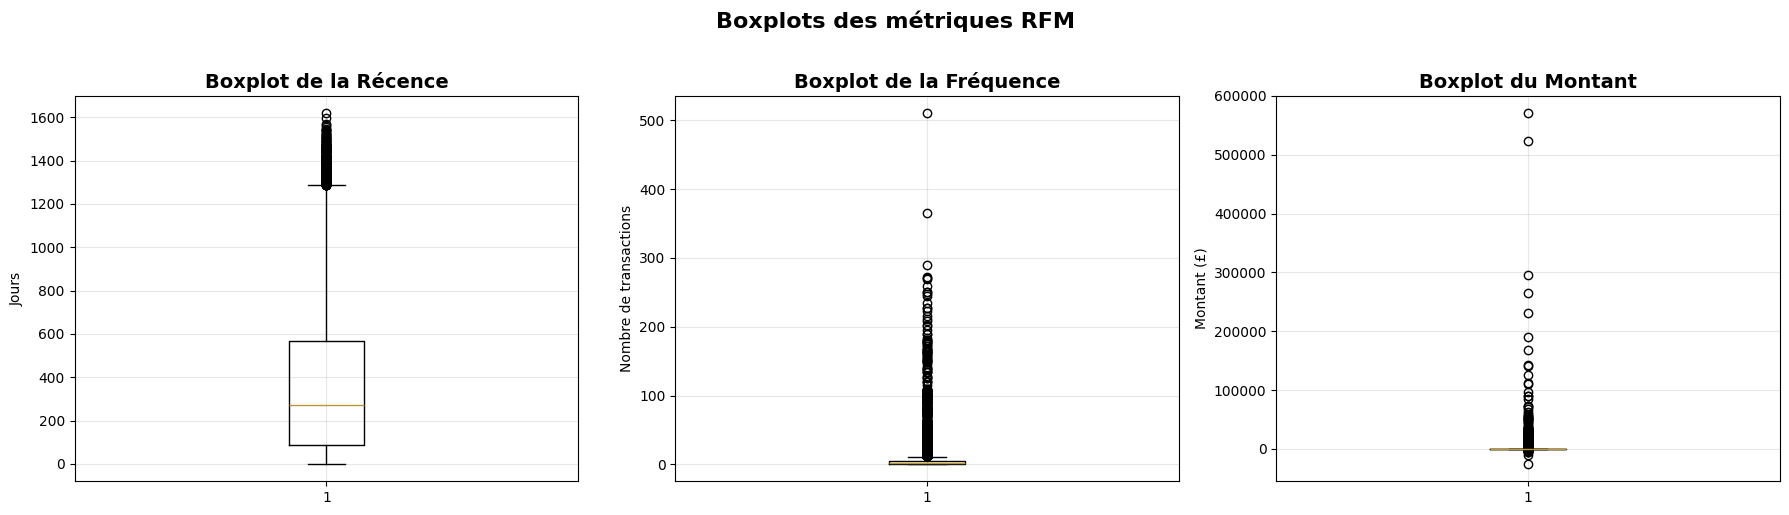

In [ ]:
# Boxplots pour identifier les valeurs aberrantes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].boxplot(rfm['Recence'], vert=True)
axes[0].set_title('Recency boxplot', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Days')
axes[0].grid(alpha=0.3)

axes[1].boxplot(rfm['Frequence'], vert=True)
axes[1].set_title('Frequency boxplot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of transactions')
axes[1].grid(alpha=0.3)

axes[2].boxplot(rfm['Montant'], vert=True)
axes[2].set_title('Monetary boxplot', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Amount (£)')
axes[2].grid(alpha=0.3)

plt.suptitle('RFM metric boxplots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

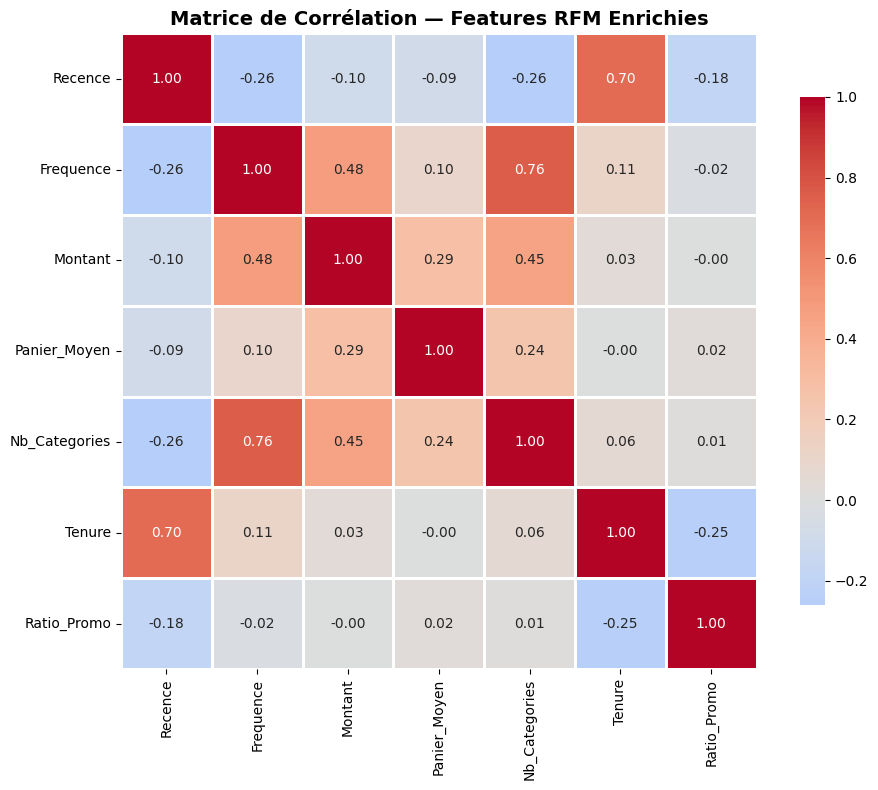


Analyse : vérifier les corrélations fortes pour éviter la redondance dans le clustering.
Fréquence vs Nb_Categories et Fréquence vs Montant sont attendues (plus on achète, plus on diversifie).


In [ ]:
# Matrice de corrélation entre toutes les features enrichies
features_all = ['Recence', 'Frequence', 'Montant', 'Panier_Moyen', 'Nb_Categories', 'Tenure', 'Ratio_Promo']
correlation_matrix = rfm[features_all].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation matrix — Enriched RFM features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nAnalyse : vérifier les corrélations fortes pour éviter la redondance dans le clustering.")
print("Fréquence vs Nb_Categories et Fréquence vs Montant sont attendues (plus on achète, plus on diversifie).")

---
## Étape 2 : Scoring RFM et premiers segments

Attribution des scores R, F, M de 1 à 5 par quintiles. Pour la Récence, un score élevé (5) = récence faible = meilleur client.

In [ ]:
# Calcul des scores RFM en quintiles (1-5)
# Note : Pour Récence, un score élevé = faible récence (meilleur)
rfm['R_Score'] = pd.qcut(rfm['Recence'], q=5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequence'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Montant'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Conversion en entiers
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Score RFM combiné
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("✓ Scores RFM calculés")
print("\nAperçu des scores :")
rfm[['customer_id', 'Recence', 'Frequence', 'Montant', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Score_Total']].head(10)

✓ Scores RFM calculés

Aperçu des scores :


,customer_id,Recence,Frequence,Montant,R_Score,F_Score,M_Score,RFM_Score,RFM_Score_Total
0,12346.0,326,17,-51.74,3,5,1,351,9
1,12347.0,2,8,4921.53,5,5,5,555,15
2,12348.0,75,5,2019.40,4,4,5,445,13
3,12349.0,19,5,4404.54,5,4,5,545,14
4,12350.0,310,1,334.40,3,1,4,314,8
5,12351.0,375,1,300.93,3,1,4,314,8
6,12352.0,36,13,1889.21,5,5,5,555,15
7,12353.0,204,2,406.76,3,3,4,334,10
8,12354.0,232,1,1079.40,3,1,5,315,9
9,12355.0,214,2,947.61,3,3,5,335,11


In [ ]:
# Segmentation RFM basée sur les scores
def segment_rfm(row):
    """Assigne un segment client basé sur les scores RFM"""
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 4:
        return 'Clients Fidèles'
    elif r >= 4 and f <= 2:
        return 'Clients Potentiels'
    elif r <= 2 and f >= 3:
        return 'À Risque'
    elif r <= 2 and f >= 2 and f <= 3:
        return 'Endormis'
    elif r <= 2 and f <= 2:
        return 'Perdus'
    else:
        return 'Occasionnels'

rfm['Segment'] = rfm.apply(segment_rfm, axis=1)

print("✓ Segmentation RFM réalisée")
print("\nDistribution des segments :")
print("="*80)
segment_counts = rfm['Segment'].value_counts().sort_values(ascending=False)
print(segment_counts)
print(f"\nTotal : {segment_counts.sum()} clients")

✓ Segmentation RFM réalisée

Distribution des segments :
Segment
Champions             9756
Occasionnels          8820
Perdus                8174
À Risque              7074
Clients Fidèles       6739
Endormis              4391
Clients Potentiels    4192
Name: count, dtype: int64

Total : 49146 clients


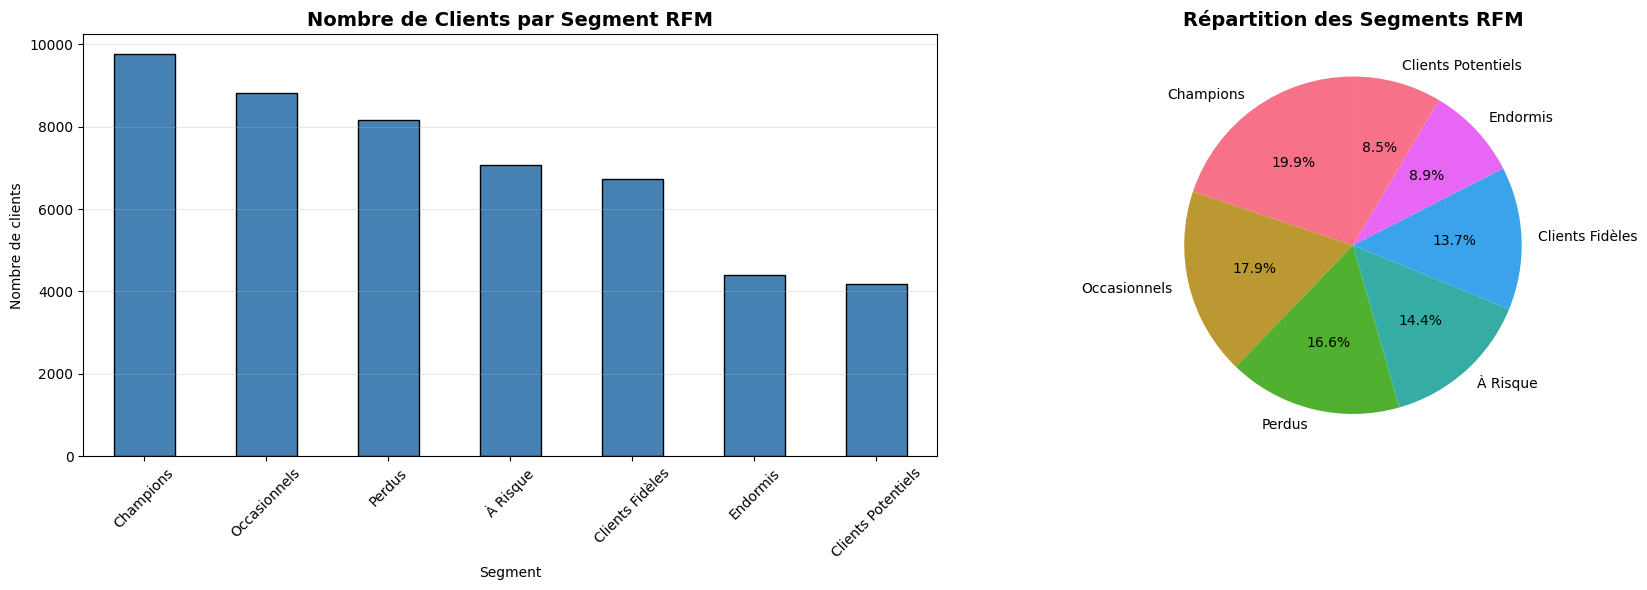

In [ ]:
# Visualisation de la distribution des segments
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Diagramme barres
segment_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Number of customers by RFM segment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of customers')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, axis='y')

# Camembert
segment_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('RFM segment distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
# Statistiques moyennes par segment
segment_stats = rfm.groupby('Segment')[['Recence', 'Frequence', 'Montant']].mean().round(2)
segment_stats['Nombre_Clients'] = rfm.groupby('Segment').size()
segment_stats = segment_stats.sort_values('Nombre_Clients', ascending=False)

print("Profil moyen de chaque segment :")
print("="*80)
segment_stats

Profil moyen de chaque segment :


,Recence,Frequence,Montant,Nombre_Clients
Segment,,,,
Champions,69.33,13.72,2312.92,9756
Occasionnels,200.75,1.79,160.24,8820
Perdus,744.88,1.00,40.16,8174
À Risque,586.29,3.36,301.70,7074
Clients Fidèles,207.20,5.68,426.62,6739
Endormis,751.13,1.00,66.80,4391
Clients Potentiels,78.23,1.00,57.58,4192


### Analyse des segments RFM

**Questions du TP** :
- **Champions (score 555 ou proche)** : à quantifier — quelle part du CA représentent-ils ?
- **À Risque** : clients à forte valeur historique mais faible récence — candidats prioritaires à la réactivation.
- **Perdus (111)** : quelle proportion de la base ? Action possible = campagne de réactivation ou exclusion des campagnes coûteuses.

> Les réponses chiffrées s'affichent dans les cellules ci-dessus après exécution.

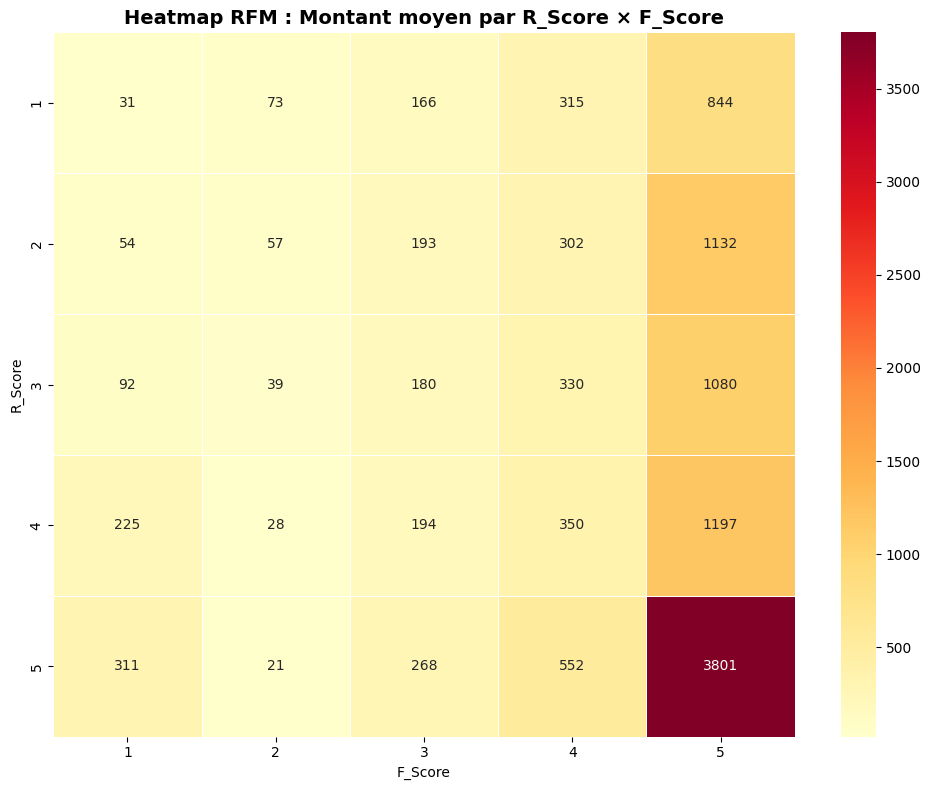

In [ ]:
# Heatmap RFM : récence × fréquence colorée par montant moyen
rfm_heatmap = rfm.groupby(['R_Score', 'F_Score'])['Montant'].mean().unstack()

plt.figure(figsize=(10, 8))
sns.heatmap(rfm_heatmap, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('RFM heatmap: Average monetary value by R_Score × F_Score', fontsize=14, fontweight='bold')
plt.xlabel('F_Score')
plt.ylabel('R_Score')
plt.tight_layout()
plt.show()

---
## Étape 3 : Clustering Hiérarchique sur features RFM enrichies

**Choix méthodologique** : clustering hiérarchique agglomératif (méthode de Ward) plutôt que K-Means.

**Justification** :
- Ward minimise la variance intra-cluster (même objectif que K-Means) mais ne nécessite pas de fixer K a priori.
- Le dendrogramme permet de visualiser la structure hiérarchique des données et de choisir K de manière informée.
- Plus robuste aux outliers que K-Means (pas de sensibilité aux centroïdes initiaux).

### 3.1 Préparation des données

**Décisions de pré-traitement** :
- **Montants négatifs** : certains clients ont un montant total négatif (plus de retours que d'achats). On clippe Montant et Panier Moyen à 0.01 avant le log-transform pour éviter les NaN. Ces clients seront naturellement regroupés dans un cluster à faible valeur.
- **Log-transform** (`np.log1p`) sur Fréquence, Montant, Panier Moyen, Nb Catégories : distributions très asymétriques (confirmé en EDA TP1). Réduit l'influence des outliers B2B sans les supprimer.
- **StandardScaler** : obligatoire — la distance euclidienne utilisée par Ward est sensible à l'échelle.
- **Pas de suppression d'outliers** : le clustering hiérarchique est plus robuste que K-Means. On laisse les outliers et on analysera s'ils forment un cluster distinct.

In [ ]:
# Sélection des features pour le clustering
features_clustering = ['Recence', 'Frequence', 'Montant', 'Panier_Moyen',
                        'Nb_Categories', 'Tenure', 'Ratio_Promo']

X = rfm[features_clustering].copy()

# Traitement des montants négatifs (clients avec plus de retours que d'achats)
nb_neg_montant = (X['Montant'] < 0).sum()
nb_neg_panier = (X['Panier_Moyen'] < 0).sum()
print(f"Clients avec Montant négatif : {nb_neg_montant}")
print(f"Clients avec Panier Moyen négatif : {nb_neg_panier}")
print("→ Décision : on clippe à 0.01 avant log-transform (ces clients sont des retours nets)")

# Clipper les valeurs négatives à 0.01 pour permettre le log-transform
X['Montant'] = X['Montant'].clip(lower=0.01)
X['Panier_Moyen'] = X['Panier_Moyen'].clip(lower=0.01)

# Log-transform des features très skewed
for col in ['Frequence', 'Montant', 'Panier_Moyen', 'Nb_Categories']:
    X[col] = np.log1p(X[col])

# Vérification : aucun NaN ou Inf ne doit subsister
assert X.isnull().sum().sum() == 0, f"NaN détectés : {X.isnull().sum()}"
assert np.isinf(X.values).sum() == 0, "Valeurs infinies détectées"
print("\n✓ Aucun NaN, aucun Inf après transformation")

print("\nDonnées avant normalisation (post log-transform) :")
print("="*80)
print(X.describe().round(2))

# Normalisation StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_clustering)

print("\n" + "="*80)
print("Données après normalisation (StandardScaler) :")
print("="*80)
print(X_scaled_df.describe().round(2))
print("\n✓ Features préparées : clip → log-transform → StandardScaler")

Clients avec Montant négatif : 91
Clients avec Panier Moyen négatif : 86
→ Décision : on clippe à 0.01 avant log-transform (ces clients sont des retours nets)

✓ Aucun NaN, aucun Inf après transformation

Données avant normalisation (post log-transform) :
        Recence  Frequence   Montant  Panier_Moyen  Nb_Categories    Tenure  \
count  49146.00   49146.00  49146.00      49146.00       49146.00  49146.00   
mean     360.26       1.34      4.64          3.74           2.20    566.13   
std      317.31       0.75      1.76          1.15           1.22    302.32   
min        1.00       0.69      0.01          0.01           0.69      1.00   
25%       88.00       0.69      3.37          2.95           1.10    354.25   
50%      270.00       1.10      4.45          3.66           2.08    590.00   
75%      568.00       1.79      5.79          4.46           3.00    751.00   
max     1618.00       6.24     13.25          9.38           7.85   1618.00   

       Ratio_Promo  
count     4

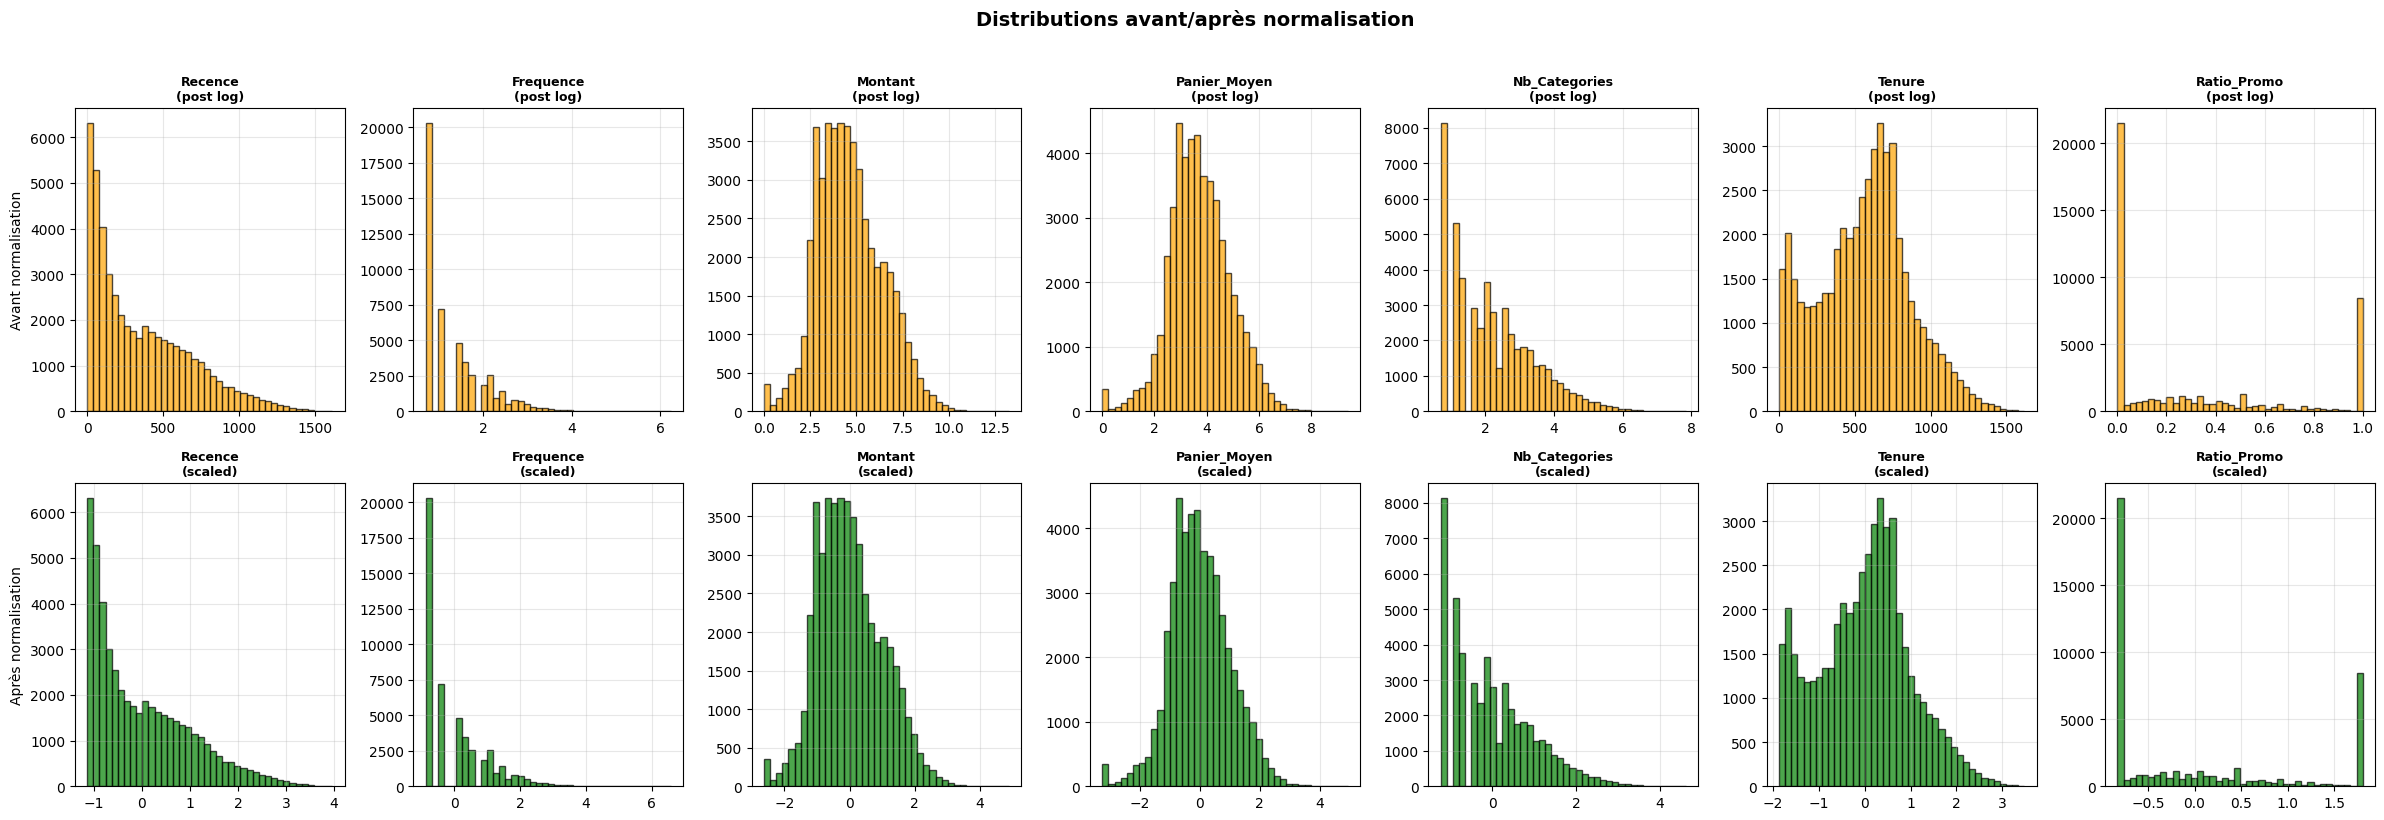

In [ ]:
# Visualisation avant/après normalisation
fig, axes = plt.subplots(2, len(features_clustering), figsize=(24, 8))

for i, col in enumerate(features_clustering):
    axes[0, i].hist(X[col], bins=40, color='orange', edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col}\n(post log)', fontsize=9, fontweight='bold')
    axes[0, i].grid(alpha=0.3)

    axes[1, i].hist(X_scaled[:, i], bins=40, color='green', edgecolor='black', alpha=0.7)
    axes[1, i].set_title(f'{col}\n(scaled)', fontsize=9, fontweight='bold')
    axes[1, i].grid(alpha=0.3)

axes[0, 0].set_ylabel('Before scaling')
axes[1, 0].set_ylabel('After scaling')
plt.suptitle('Distributions before/after scaling', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Dendrogramme exploratoire

Méthode de Ward (minimise la variance intra-cluster). On utilise un échantillon de 2000 clients pour la lisibilité du dendrogramme. Les grands sauts verticaux indiquent des fusions de clusters très différents → coupures naturelles.

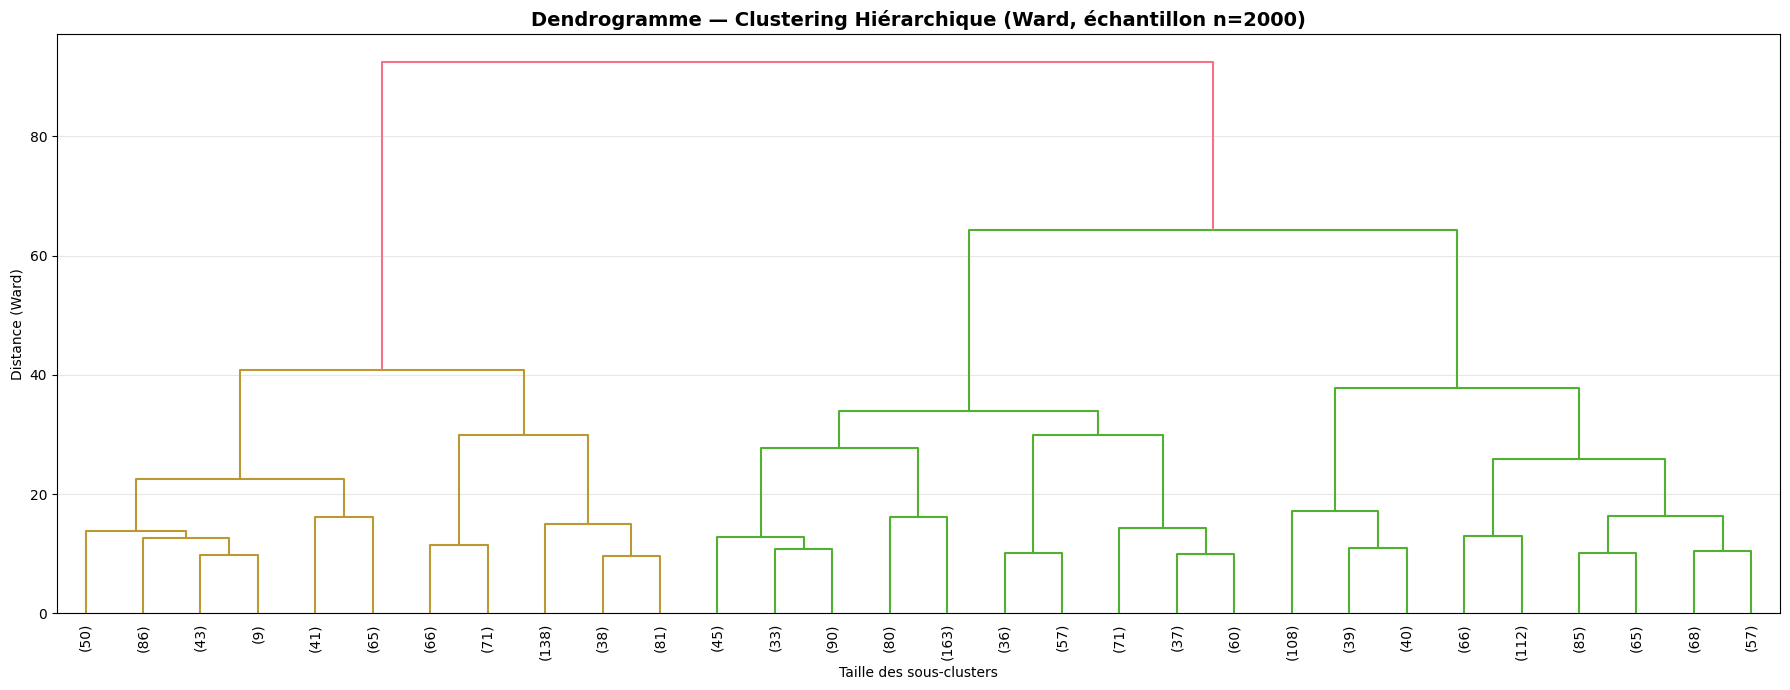

→ Observer les paliers de distance pour identifier le nombre naturel de clusters


In [ ]:
# Dendrogramme exploratoire sur échantillon
sample_size = min(2000, len(X_scaled))
np.random.seed(888)
idx_sample = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[idx_sample]

# Linkage Ward
Z_sample = linkage(X_sample, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(18, 7))
dendrogram(Z_sample, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=10, show_leaf_counts=True, ax=ax,
           color_threshold=0.7 * max(Z_sample[:, 2]))
ax.set_title('Dendrogram — Hierarchical clustering (Ward, sample n=2000)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sub-cluster size')
ax.set_ylabel('Distance (Ward)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("→ Observer les paliers de distance pour identifier le nombre naturel de clusters")

### 3.3 Détermination du nombre optimal de clusters

On croise deux méthodes sur le dataset complet :
- **Méthode du coude** : on cherche le "coude" dans la courbe d'inertie (variance intra-cluster)
- **Score de silhouette** : on cherche le maximum (meilleure séparation inter-cluster)

In [ ]:
# Linkage sur le dataset complet
Z_full = linkage(X_scaled, method='ward', metric='euclidean')

K_range = 5
silhouette_scores_hc = []
inertias_hc = []

print("Calcul inertie + silhouette pour K = 2 à 12 :")
for k in K_range:
    labels = fcluster(Z_full, t=k, criterion='maxclust')
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores_hc.append(sil)

    # Inertie = somme des distances au centroïde par cluster
    inertia = 0
    for c in np.unique(labels):
        cluster_points = X_scaled[labels == c]
        centroid = cluster_points.mean(axis=0)
        inertia += ((cluster_points - centroid) ** 2).sum()
    inertias_hc.append(inertia)

    print(f"  K={k:2d} : Silhouette={sil:.4f}, Inertie={inertia:.2f}")

print("\n✓ Calculs terminés")

Calcul inertie + silhouette pour K = 2 à 12 :
  K= 2 : Silhouette=0.2811, Inertie=238299.21
  K= 3 : Silhouette=0.2569, Inertie=185741.80
  K= 4 : Silhouette=0.2291, Inertie=166136.71
  K= 5 : Silhouette=0.1930, Inertie=152676.84
  K= 6 : Silhouette=0.2028, Inertie=139507.48
  K= 7 : Silhouette=0.1724, Inertie=129625.06
  K= 8 : Silhouette=0.1826, Inertie=119847.73
  K= 9 : Silhouette=0.1782, Inertie=111609.37
  K=10 : Silhouette=0.1876, Inertie=103929.31
  K=11 : Silhouette=0.1882, Inertie=98804.65
  K=12 : Silhouette=0.1888, Inertie=94498.88

✓ Calculs terminés


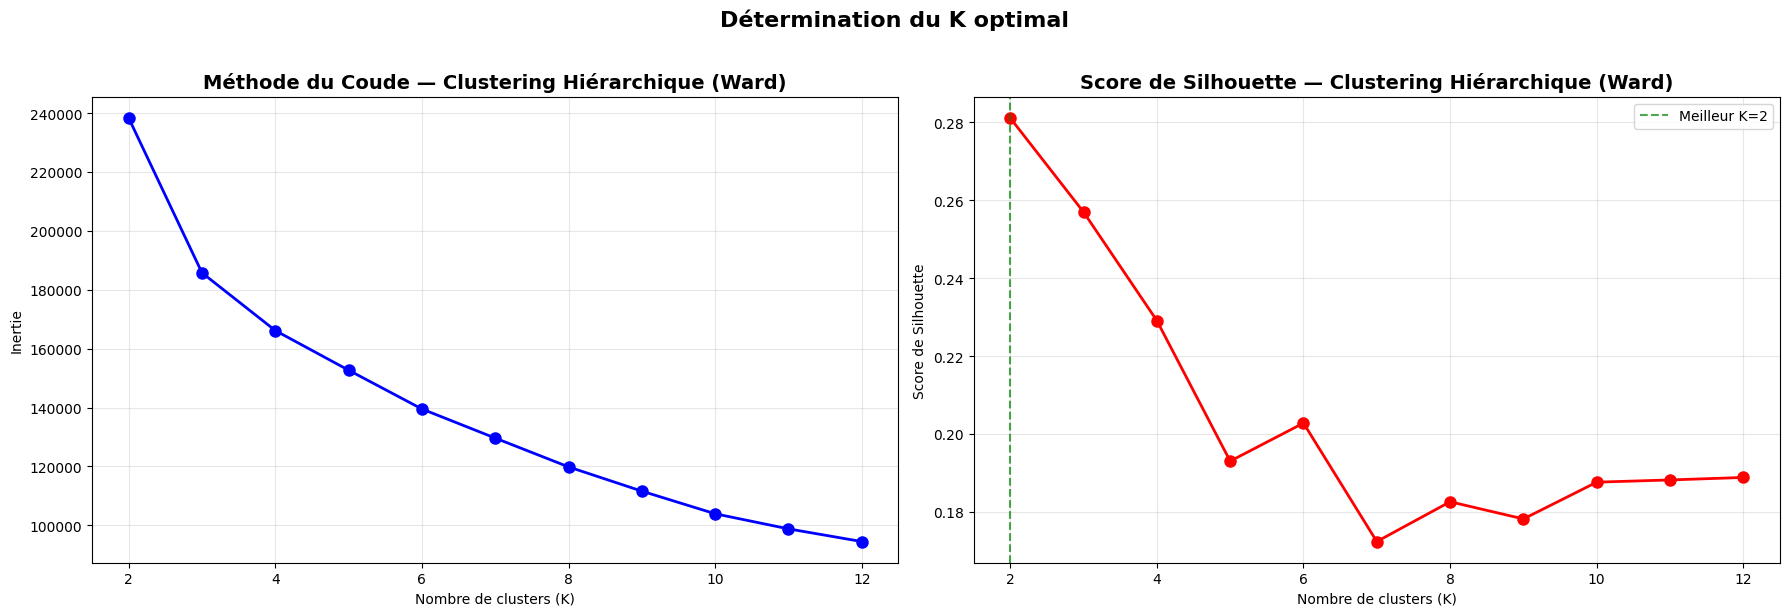


→ Meilleur score de silhouette : K=2 (silhouette=0.2811)
→ Croiser avec la méthode du coude pour le choix final de K.


In [ ]:
# Visualisation coude + silhouette
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(K_range, inertias_hc, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method — Hierarchical clustering (Ward)', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouette_scores_hc, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score — Hierarchical clustering (Ward)', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

# Marquer le meilleur silhouette
best_k_sil = list(K_range)[np.argmax(silhouette_scores_hc)]
axes[1].axvline(x=best_k_sil, color='green', linestyle='--', alpha=0.7, label=f'Best K={best_k_sil}')
axes[1].legend()

plt.suptitle('Selecting the optimal K', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n→ Meilleur score de silhouette : K={best_k_sil} (silhouette={max(silhouette_scores_hc):.4f})")
print("→ Croiser avec la méthode du coude pour le choix final de K.")

### Choix de K

**Analyse croisée** :
- Méthode du coude : le coude apparaît autour de K = [À COMPLÉTER après exécution]
- Score de silhouette : maximum à K = [À COMPLÉTER après exécution]
- Dendrogramme : [À COMPLÉTER — cohérent avec les paliers observés ?]

**Décision finale** : K = [À COMPLÉTER] — justification ci-dessus.

> ⚠️ Ajustez la variable `optimal_k` dans la cellule suivante en fonction de vos résultats.

In [ ]:
# ============================================
# AJUSTER ICI après lecture des courbes
optimal_k = 5
# ============================================

labels_hc = fcluster(Z_full, t=optimal_k, criterion='maxclust')
rfm['Cluster_HC'] = labels_hc

print(f"✓ Clustering hiérarchique appliqué avec K={optimal_k}")
print(f"  Score de silhouette : {silhouette_score(X_scaled, labels_hc):.4f}")
print(f"\nDistribution des clusters :")
print("="*80)
print(rfm['Cluster_HC'].value_counts().sort_index())

✓ Clustering hiérarchique appliqué avec K=5
  Score de silhouette : 0.1930

Distribution des clusters :
Cluster_HC
1     3318
2    12073
3    15863
4     6098
5    11794
Name: count, dtype: int64


In [ ]:
# Profil descriptif par cluster — moyennes et médianes
cluster_profile = rfm.groupby('Cluster_HC')[features_clustering].agg(['mean', 'median']).round(2)
print("Profils moyens et médians par cluster :")
print("="*80)
cluster_profile

Profils moyens et médians par cluster :


Recence        Frequence         Montant          Panier_Moyen  \
              mean median      mean median     mean   median         mean   
Cluster_HC                                                                  
1            63.12   36.0     25.23   18.0  5374.18  2649.48       230.86   
2           205.09  150.0      6.55    6.0   801.09   527.97       166.00   
3           734.58  695.0      1.55    1.0    61.56    36.51        40.37   
4           192.71   81.0      1.52    1.0    39.08    26.10        26.47   
5           185.88  174.0      2.69    2.0    96.02    64.90        40.90   

                   Nb_Categories         Tenure        Ratio_Promo         
            median          mean median    mean median        mean median  
Cluster_HC                                                                 
1           160.42        152.27  106.0  663.39  685.0        0.32   0.30  
2            93.92         31.40   25.0  598.83  624.0        0.31   0.23  
3            28.44          4.56    3.0  810.02  789.0        0.19   0.00  
4            18.92          3.71    2.0  247.06   88.0        0.93   1.00  
5            26.69          7.59    6.0  342.25  309.0        0.17   0.00

In [ ]:
# Profil synthétique + part du CA
profile_summary = rfm.groupby('Cluster_HC').agg(
    Nb_Clients=('customer_id', 'count'),
    Recence_Moy=('Recence', 'mean'),
    Recence_Med=('Recence', 'median'),
    Frequence_Moy=('Frequence', 'mean'),
    Montant_Moy=('Montant', 'mean'),
    Montant_Med=('Montant', 'median'),
    Panier_Moyen_Moy=('Panier_Moyen', 'mean'),
    Nb_Categories_Moy=('Nb_Categories', 'mean'),
    Tenure_Moy=('Tenure', 'mean'),
    Ratio_Promo_Moy=('Ratio_Promo', 'mean'),
    Montant_Total=('Montant', 'sum')
).round(1)

profile_summary['%_Clients'] = (profile_summary['Nb_Clients'] / len(rfm) * 100).round(1)
profile_summary['%_CA'] = (profile_summary['Montant_Total'] / rfm['Montant'].sum() * 100).round(1)

print("Profil synthétique par cluster :")
print("="*80)
profile_summary

Profil synthétique par cluster :


,Nb_Clients,Recence_Moy,Recence_Med,Frequence_Moy,Montant_Moy,Montant_Med,Panier_Moyen_Moy,Nb_Categories_Moy,Tenure_Moy,Ratio_Promo_Moy,Montant_Total,%_Clients,%_CA
Cluster_HC,,,,,,,,,,,,,
1,3318,63.1,36.0,25.2,5374.2,2649.5,230.9,152.3,663.4,0.3,17831528.4,6.8,59.7
2,12073,205.1,150.0,6.5,801.1,528.0,166.0,31.4,598.8,0.3,9671522.8,24.6,32.4
3,15863,734.6,695.0,1.5,61.6,36.5,40.4,4.6,810.0,0.2,976500.9,32.3,3.3
4,6098,192.7,81.0,1.5,39.1,26.1,26.5,3.7,247.1,0.9,238297.3,12.4,0.8
5,11794,185.9,174.0,2.7,96.0,64.9,40.9,7.6,342.3,0.2,1132486.4,24.0,3.8


### Interprétation des clusters

**Nommage marketing** : un cluster sans nom n'est pas actionnable. On attribue un nom basé sur le profil comportemental observé.

> Examiner les profils ci-dessus (récence, fréquence, montant, panier moyen, tenure, ratio promo, % CA) pour donner un nom pertinent à chaque cluster.

In [ ]:
# Nommage des clusters — à ajuster selon les profils observés
# Afficher les profils pour aider au nommage
print("PROFILS À NOMMER :")
print("="*80)
for cluster_id in sorted(rfm['Cluster_HC'].unique()):
    subset = rfm[rfm['Cluster_HC'] == cluster_id]
    print(f"\n--- Cluster {cluster_id} ({len(subset)} clients, {len(subset)/len(rfm)*100:.1f}%) ---")
    print(f"  Récence:      {subset['Recence'].median():.0f}j (médiane)")
    print(f"  Fréquence:    {subset['Frequence'].median():.0f} commandes")
    print(f"  Montant:      £{subset['Montant'].median():.0f} (médiane), £{subset['Montant'].sum():.0f} (total)")
    print(f"  Panier moyen: £{subset['Panier_Moyen'].median():.0f}")
    print(f"  Catégories:   {subset['Nb_Categories'].median():.0f}")
    print(f"  Tenure:       {subset['Tenure'].median():.0f}j")
    print(f"  Ratio promo:  {subset['Ratio_Promo'].median():.1%}")
    print(f"  % du CA:      {subset['Montant'].sum()/rfm['Montant'].sum()*100:.1f}%")

PROFILS À NOMMER :

--- Cluster 1 (3318 clients, 6.8%) ---
  Récence:      36j (médiane)
  Fréquence:    18 commandes
  Montant:      £2649 (médiane), £17831528 (total)
  Panier moyen: £160
  Catégories:   106
  Tenure:       685j
  Ratio promo:  29.8%
  % du CA:      59.7%

--- Cluster 2 (12073 clients, 24.6%) ---
  Récence:      150j (médiane)
  Fréquence:    6 commandes
  Montant:      £528 (médiane), £9671523 (total)
  Panier moyen: £94
  Catégories:   25
  Tenure:       624j
  Ratio promo:  22.7%
  % du CA:      32.4%

--- Cluster 3 (15863 clients, 32.3%) ---
  Récence:      695j (médiane)
  Fréquence:    1 commandes
  Montant:      £37 (médiane), £976501 (total)
  Panier moyen: £28
  Catégories:   3
  Tenure:       789j
  Ratio promo:  0.0%
  % du CA:      3.3%

--- Cluster 4 (6098 clients, 12.4%) ---
  Récence:      81j (médiane)
  Fréquence:    1 commandes
  Montant:      £26 (médiane), £238297 (total)
  Panier moyen: £19
  Catégories:   2
  Tenure:       88j
  Ratio promo:  10

In [ ]:
# =============================================================
# NOMMAGE : à modifier selon les résultats après exécution
# =============================================================
cluster_names = {
    1: 'À compléter',
    2: 'À compléter',
    3: 'À compléter',
    4: 'À compléter',
    5: 'À compléter',
}

rfm['Cluster_Nom'] = rfm['Cluster_HC'].map(cluster_names)

print("✓ Clusters nommés :")
print(rfm['Cluster_Nom'].value_counts())

✓ Clusters nommés :
Cluster_Nom
À compléter    49146
Name: count, dtype: int64


---
## Étape 4 : Comparaison RFM vs Clustering Hiérarchique

Le tableau de contingence croise les segments RFM (règles métier manuelles) avec les clusters hiérarchiques (détection automatique de patterns multi-dimensionnels).

**Questions clés** :
- Quels segments RFM correspondent bien à un seul cluster ?
- Quel segment RFM se retrouve splitté en plusieurs clusters ? Pourquoi ?
- Le clustering capte-t-il des nuances que le RFM manque (ex: distinction B2C/B2B) ?

In [ ]:
# Tableau de contingence
contingency = pd.crosstab(rfm['Segment'], rfm['Cluster_HC'], margins=True, margins_name='Total')
print("Tableau de contingence — Segments RFM × Clusters HC :")
print("="*80)
print(contingency)

Tableau de contingence — Segments RFM × Clusters HC :
Cluster_HC             1      2      3     4      5  Total
Segment                                                   
Champions           3009   5509      2    19   1217   9756
Clients Fidèles      234   2947    181   357   3020   6739
Clients Potentiels     0    280    106  2478   1328   4192
Endormis               0    121   3805   465      0   4391
Occasionnels          44   1195    255  1430   5896   8820
Perdus                 0    466   7026   682      0   8174
À Risque              31   1555   4488   667    333   7074
Total               3318  12073  15863  6098  11794  49146


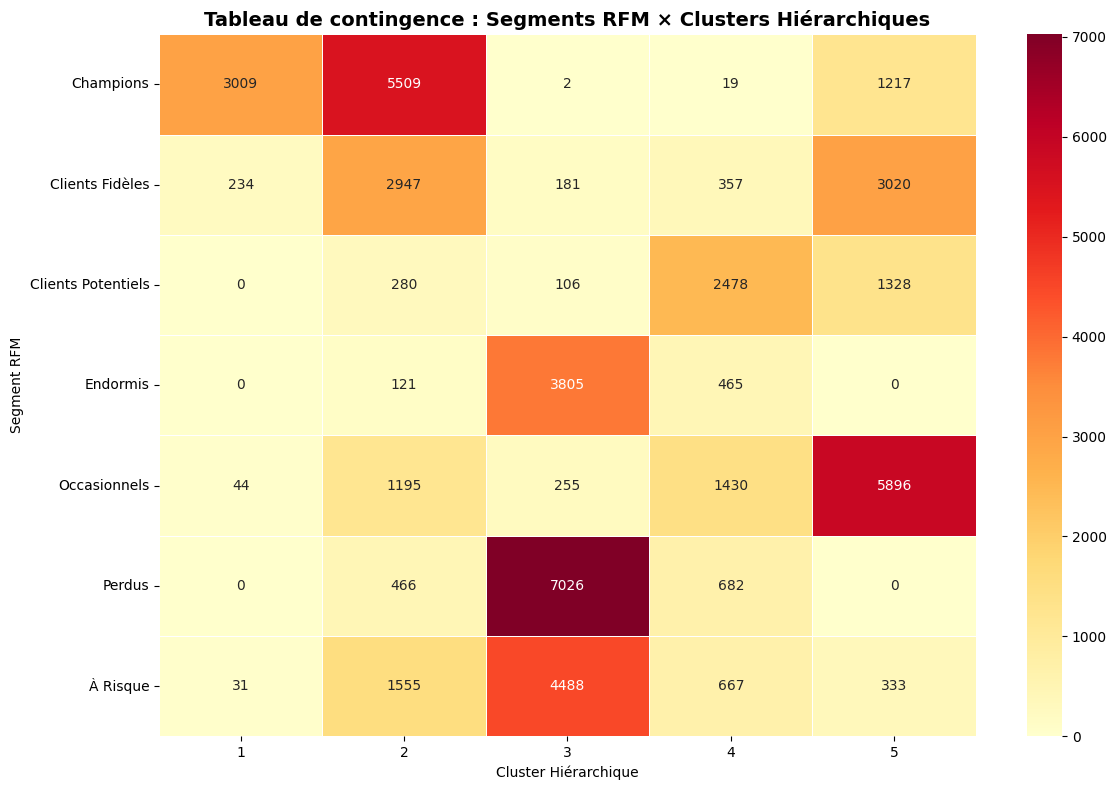

In [ ]:
# Heatmap du tableau de contingence
contingency_no_margins = pd.crosstab(rfm['Segment'], rfm['Cluster_HC'])

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(contingency_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Contingency table: RFM segments × Hierarchical clusters', fontsize=14, fontweight='bold')
ax.set_xlabel('Hierarchical cluster')
ax.set_ylabel('RFM segment')
plt.tight_layout()
plt.show()

### Analyse des concordances et divergences

- **Concordances** : [À COMPLÉTER — quels segments RFM sont bien capturés par un cluster unique ?]
- **Divergences** : [À COMPLÉTER — quel segment RFM est splitté ? Le clustering enrichi distingue-t-il des sous-profils invisibles au RFM simple ?]
- **Valeur ajoutée du clustering** : les features enrichies (panier moyen, nb catégories, tenure, ratio promo) permettent de distinguer des comportements que le scoring RFM en 3 dimensions ne capte pas.

---
## Étape 5 : Visualisation et profilage final

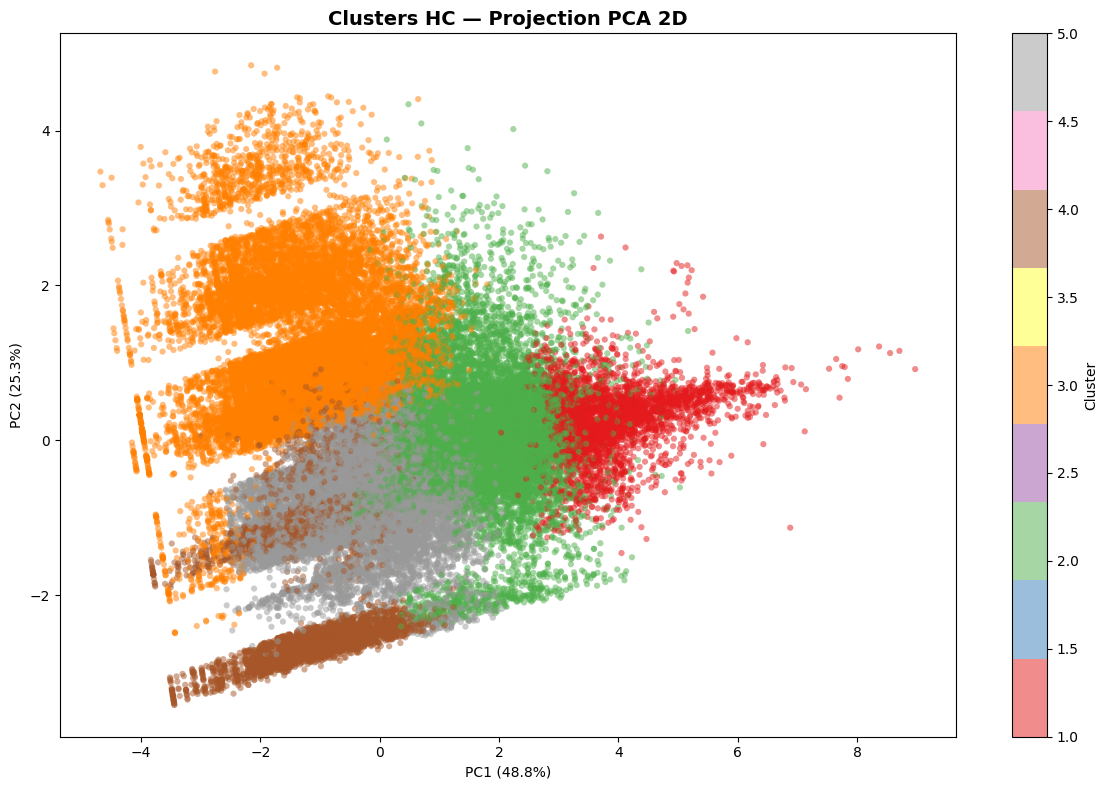

Variance expliquée par PC1+PC2 : 74.1%
→ Si < 70%, la projection 2D est partielle. t-SNE offre une meilleure visualisation.


In [ ]:
# 5.1 — PCA (quick look)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=rfm['Cluster_HC'],
                     cmap='Set1', alpha=0.5, s=20, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('HC clusters — PCA 2D projection', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

print(f"Variance expliquée par PC1+PC2 : {pca.explained_variance_ratio_.sum()*100:.1f}%")
print("→ Si < 70%, la projection 2D est partielle. t-SNE offre une meilleure visualisation.")

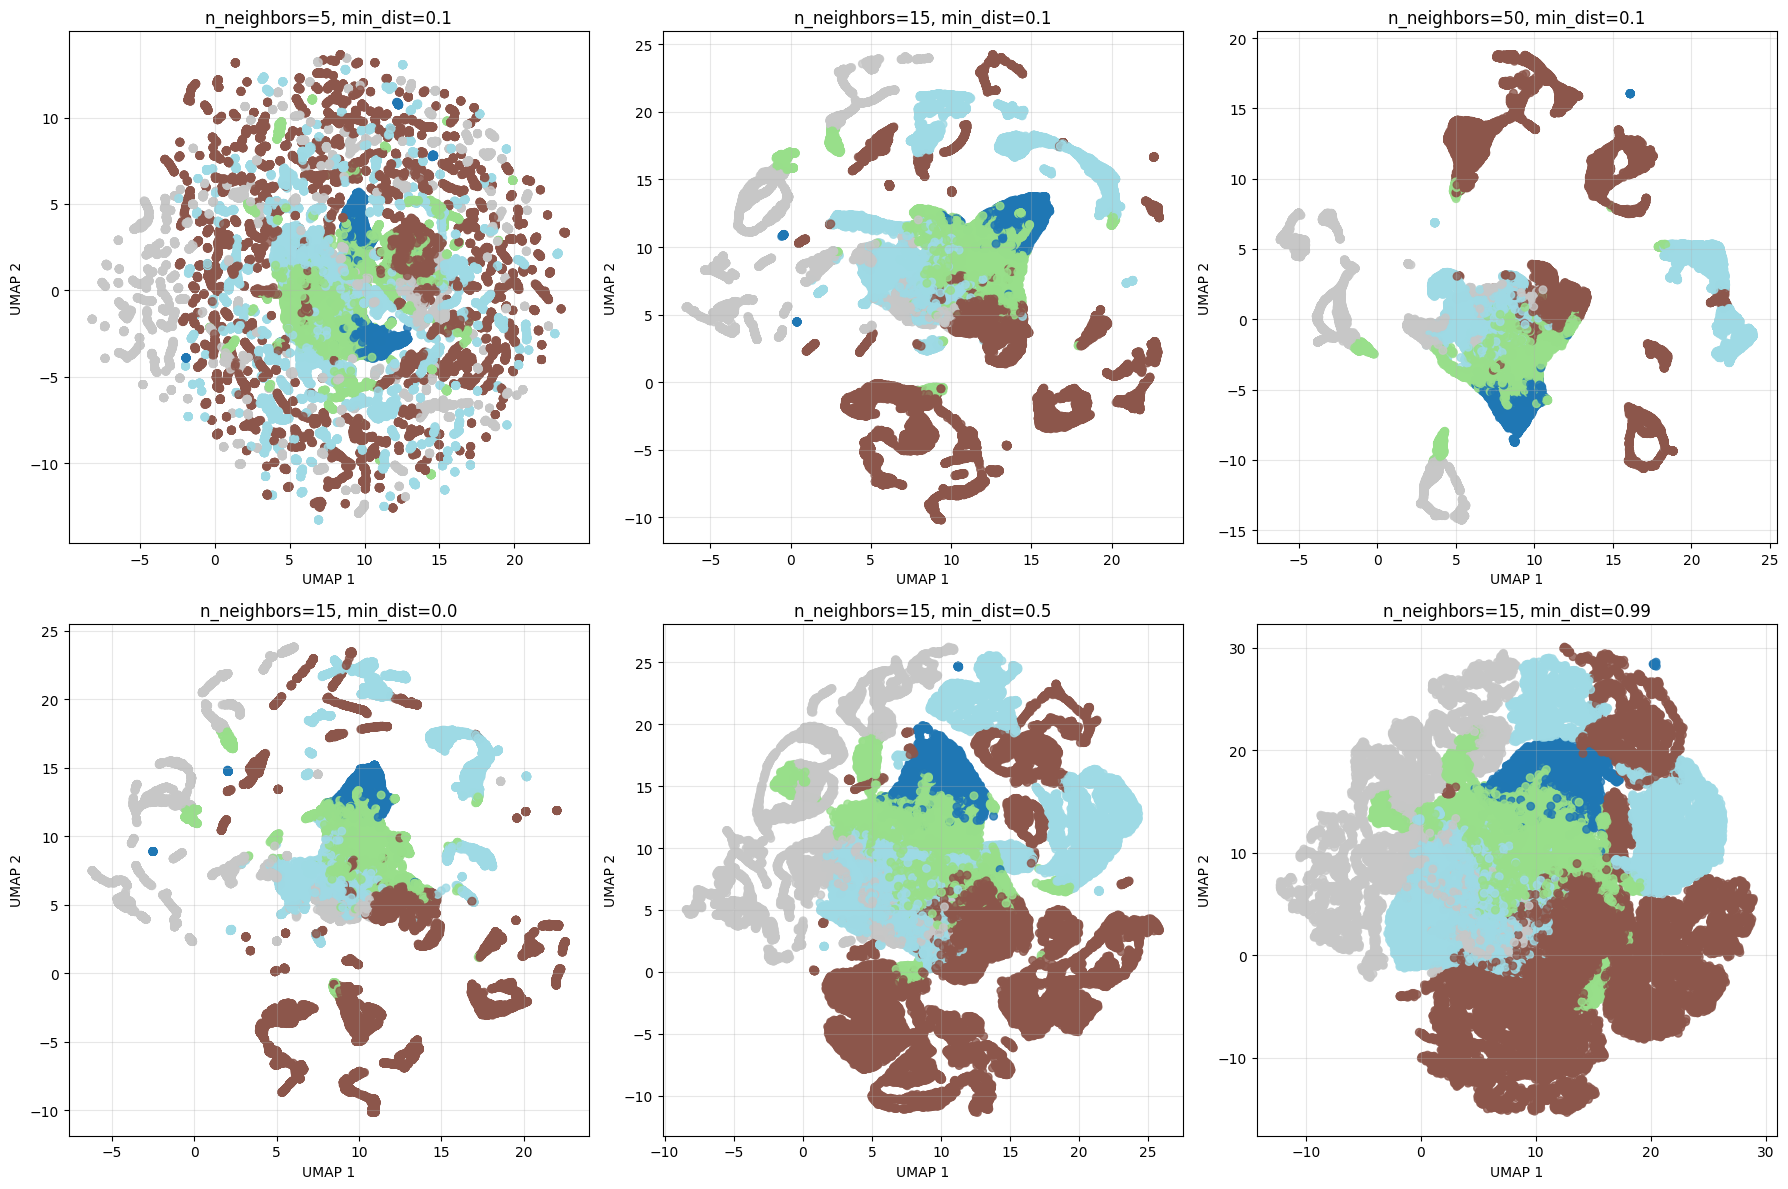

In [ ]:
import umap

# Trouvez meilleur n_neighbors et min_dist pour la visualisation
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

param_configs = [
   {'n_neighbors': 5, 'min_dist': 0.1},
   {'n_neighbors': 15, 'min_dist': 0.1},
   {'n_neighbors': 50, 'min_dist': 0.1},
   {'n_neighbors': 15, 'min_dist': 0.0},
   {'n_neighbors': 15, 'min_dist': 0.5},
   {'n_neighbors': 15, 'min_dist': 0.99}
]

for idx, params in enumerate(param_configs):
   reducer = umap.UMAP(random_state=99, **params)
   embedding = reducer.fit_transform(X_scaled)
  
   ax = axes[idx]
   scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=rfm['Cluster_HC'],
                       cmap='tab20', s=30, alpha=0.8)
   ax.set_title(f"n_neighbors={params['n_neighbors']}, "
                f"min_dist={params['min_dist']}")
   ax.set_xlabel('UMAP 1')
   ax.set_ylabel('UMAP 2')
   ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

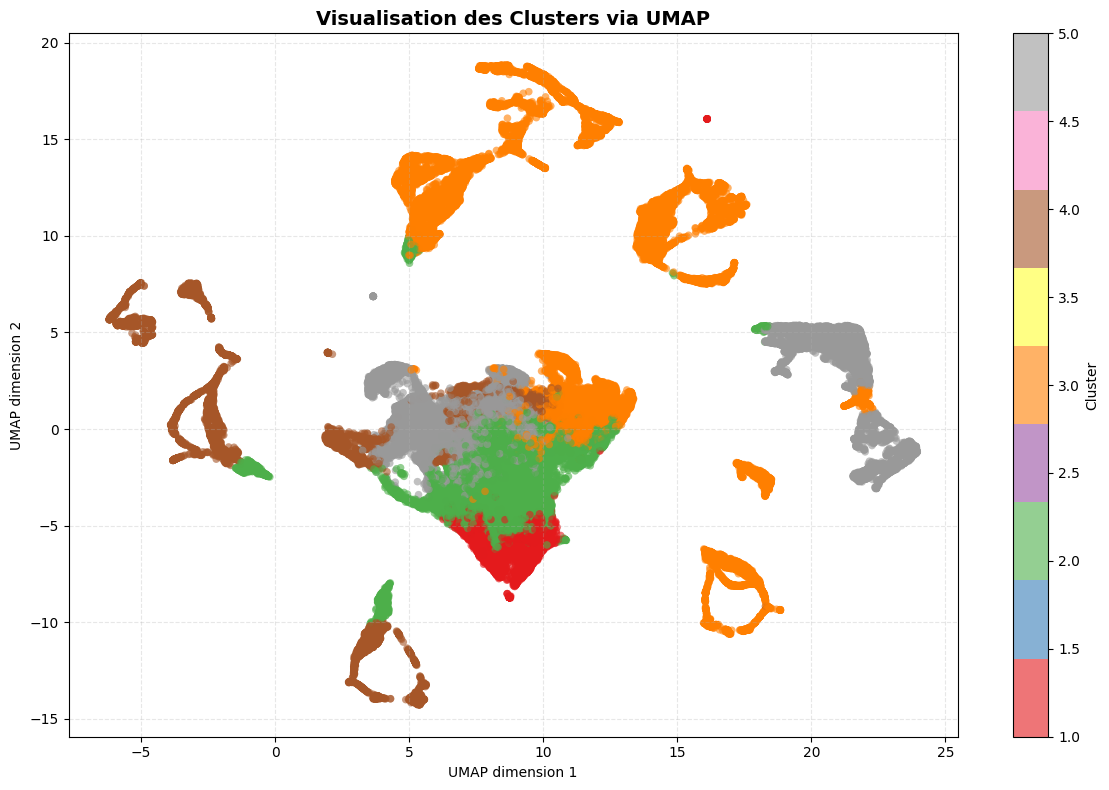

In [ ]:
import umap

# UMAP 
reducer = umap.UMAP(n_neighbors=50, min_dist=0.1, n_components=2, random_state=99)
X_umap = reducer.fit_transform(X_scaled)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=rfm['Cluster_HC'], 
                     cmap='Set1', alpha=0.6, s=30, edgecolors='none')

ax.set_xlabel('UMAP dimension 1')
ax.set_ylabel('UMAP dimension 2')
ax.set_title('Cluster visualization with UMAP', fontsize=14, fontweight='bold')

plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

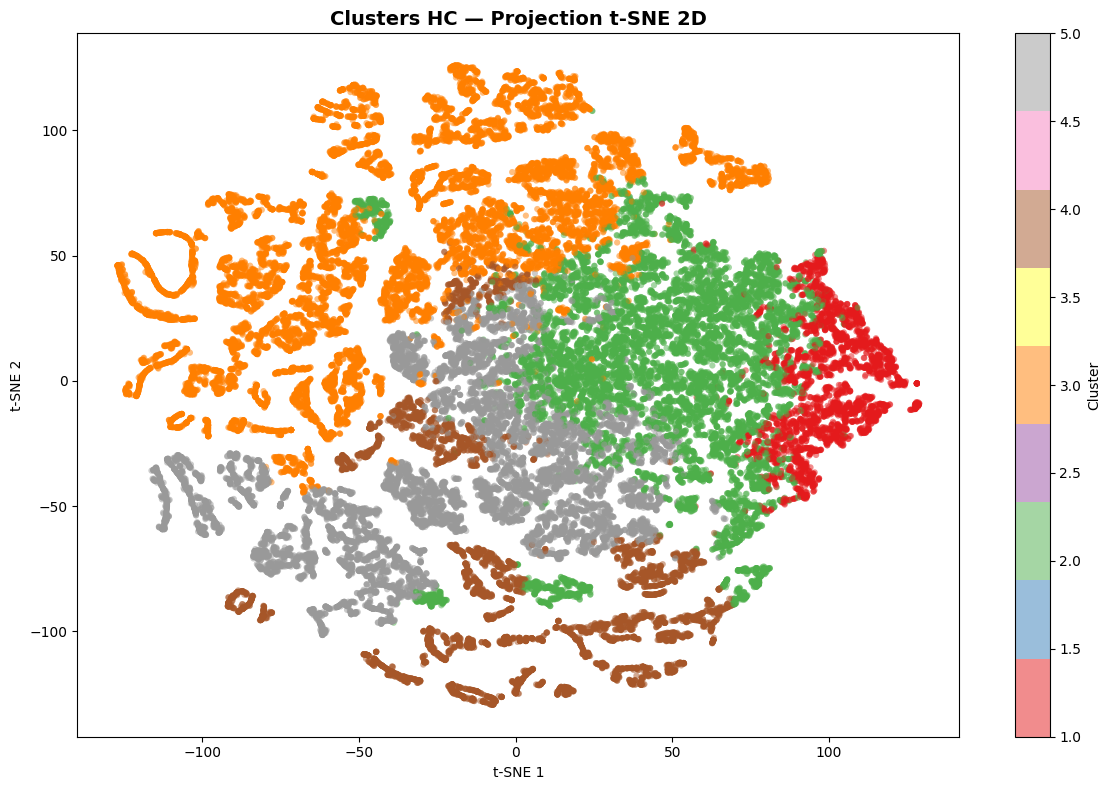

→ t-SNE préserve mieux les structures locales que PCA pour la visualisation.


In [ ]:
# 5.2 — t-SNE (visualisation finale non-linéaire)
tsne = TSNE(n_components=2, random_state=888, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=rfm['Cluster_HC'],
                     cmap='Set1', alpha=0.5, s=20, edgecolors='none')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('HC clusters — t-SNE 2D projection', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

print("→ t-SNE préserve mieux les structures locales que PCA pour la visualisation.")

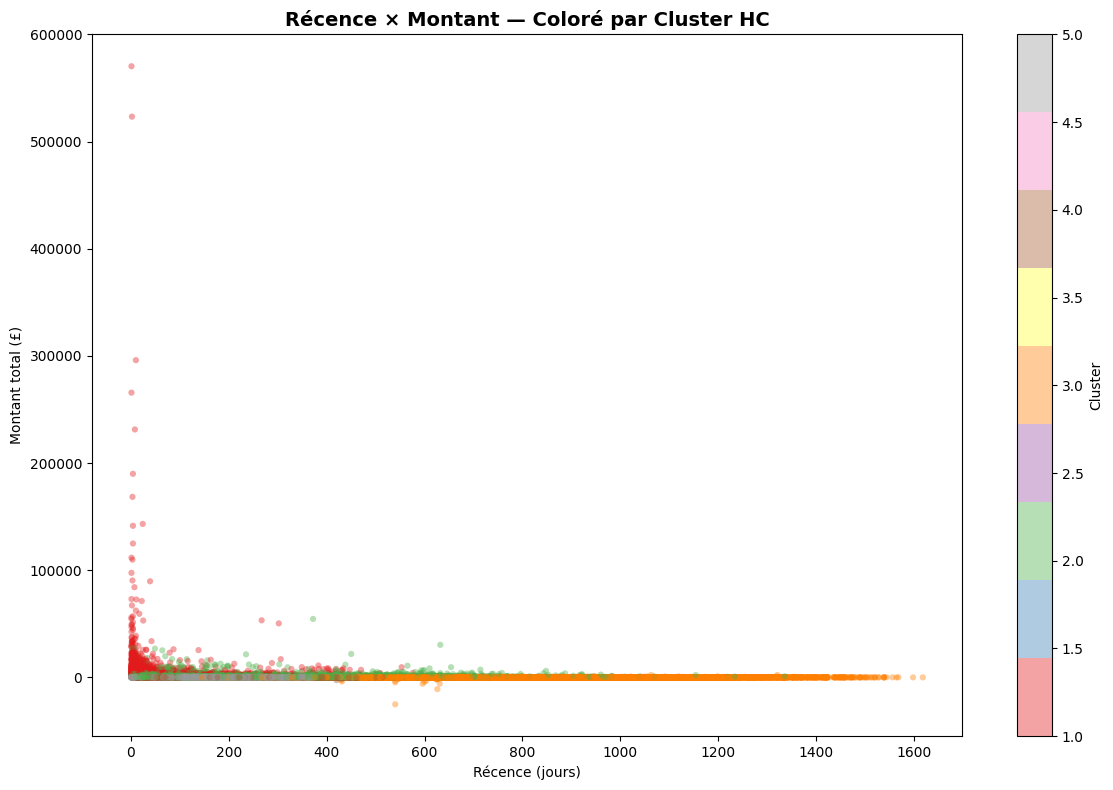

In [ ]:
# 5.3 — Scatter Récence × Montant coloré par cluster
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(rfm['Recence'], rfm['Montant'], c=rfm['Cluster_HC'],
                     cmap='Set1', alpha=0.4, s=20, edgecolors='none')
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Total amount (£)')
ax.set_title('Recency × Monetary — Colored by HC cluster', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

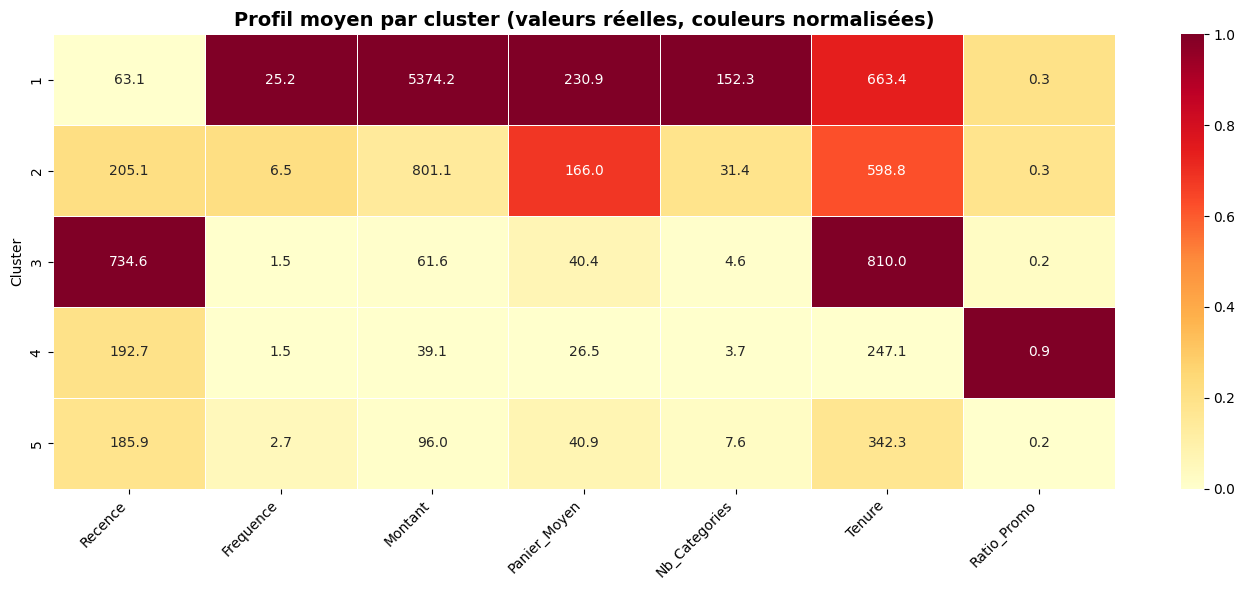

In [ ]:
# 5.4 — Heatmap des features moyennes par cluster (valeurs réelles, couleurs normalisées)
cluster_means = rfm.groupby('Cluster_HC')[features_clustering].mean()

# Normalisation min-max pour comparabilité visuelle
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(cluster_means_norm, annot=cluster_means.round(1).values,
            fmt='', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Average profile by cluster (actual values, normalized colors)', fontsize=14, fontweight='bold')
ax.set_ylabel('Cluster')
ax.set_xticklabels(features_clustering, rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# 5.5 — Profil géographique par cluster
if 'country' in df_clean.columns:
    geo_profile = df_clean[['customer_id', 'country']].drop_duplicates().merge(
        rfm[['customer_id', 'Cluster_HC']], on='customer_id'
    )

    print("Profil géographique par cluster (top 5 pays) :")
    print("="*80)
    for cluster in sorted(rfm['Cluster_HC'].unique()):
        sub = geo_profile[geo_profile['Cluster_HC'] == cluster]
        top = sub['country'].value_counts().head(5)
        total = len(sub)
        print(f"\nCluster {cluster} :")
        for country, count in top.items():
            print(f"  {country}: {count} ({count/total*100:.1f}%)")
else:
    print("Colonne 'country' non trouvée — profil géographique non disponible.")

Profil géographique par cluster (top 5 pays) :

Cluster 1 :
  United Kingdom: 3084 (92.7%)
  Germany: 68 (2.0%)
  France: 39 (1.2%)
  EIRE: 28 (0.8%)
  Belgium: 14 (0.4%)

Cluster 2 :
  United Kingdom: 10914 (90.4%)
  Germany: 295 (2.4%)
  France: 214 (1.8%)
  Spain: 70 (0.6%)
  Belgium: 51 (0.4%)

Cluster 3 :
  United Kingdom: 14661 (92.4%)
  Germany: 203 (1.3%)
  France: 127 (0.8%)
  Spain: 101 (0.6%)
  Netherlands: 84 (0.5%)

Cluster 4 :
  United Kingdom: 5521 (90.5%)
  Germany: 135 (2.2%)
  France: 105 (1.7%)
  Spain: 49 (0.8%)
  Portugal: 37 (0.6%)

Cluster 5 :
  United Kingdom: 10515 (89.2%)
  Germany: 269 (2.3%)
  France: 238 (2.0%)
  Belgium: 130 (1.1%)
  Spain: 78 (0.7%)


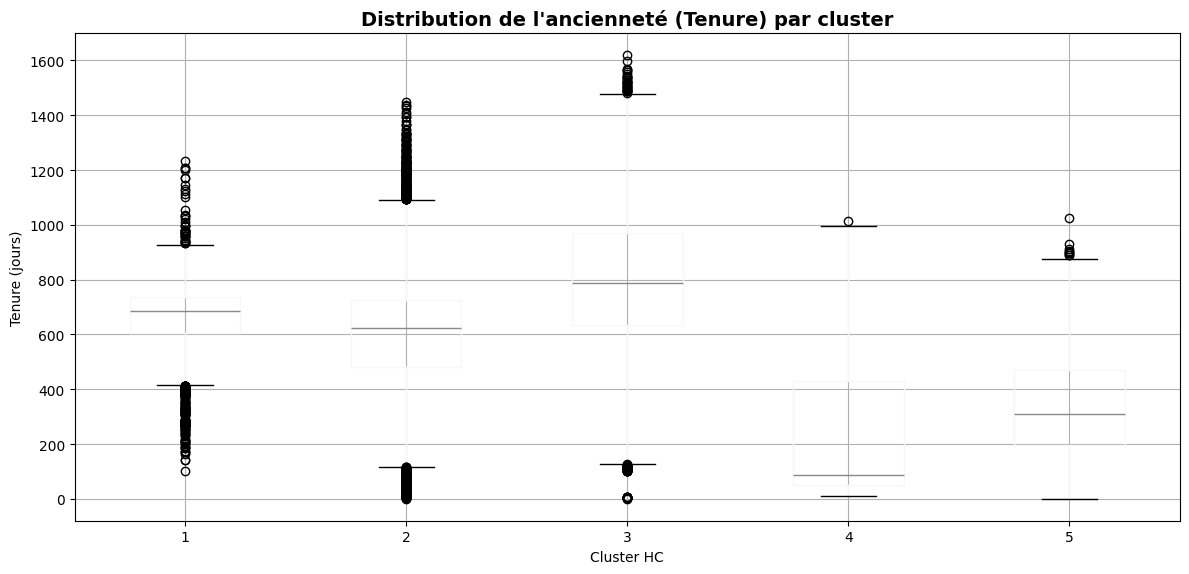

In [ ]:
# 5.6 — Profil d'ancienneté par cluster (boxplot Tenure)
fig, ax = plt.subplots(figsize=(12, 6))
rfm.boxplot(column='Tenure', by='Cluster_HC', ax=ax)
ax.set_title('Tenure distribution by cluster', fontsize=14, fontweight='bold')
ax.set_xlabel('HC cluster')
ax.set_ylabel('Tenure (days)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
# Fonction pour nommer et interpréter les clusters
def interpreter_cluster(cluster_id, profile):
    """Interprète un cluster basé sur son profil RFM"""
    r = profile['Recence']
    f = profile['Frequence']
    m = profile['Montant']
    
    interpretations = {
        'nom': f'Cluster {cluster_id}',
        'description': '',
        'strategie': ''
    }
    
    # interprétation basée sur les moyennes
    if r < 100 and f > 100 and m > 2000:
        interpretations['nom'] = 'Champions'
        interpretations['description'] = 'Clients très actifs, achats récents, fréquents et montants élevés'
        interpretations['strategie'] = 'Programme VIP, offres exclusives, récompenses de fidélité'
    
    elif r < 150 and f > 50:
        interpretations['nom'] = 'Clients Fidèles'
        interpretations['description'] = 'Clients réguliers avec bonne récence et fréquence'
        interpretations['strategie'] = 'Cross-selling, upselling, recommandations personnalisées'
    
    elif r > 200 and m > 1000:
        interpretations['nom'] = 'Clients à Réactiver'
        interpretations['description'] = 'Clients de valeur mais inactifs depuis longtemps'
        interpretations['strategie'] = 'Campagnes de réactivation, offres de retour, enquêtes de satisfaction'
    
    elif f < 30 and m < 500:
        interpretations['nom'] = 'Nouveaux/Occasionnels'
        interpretations['description'] = 'Clients peu actifs ou nouveaux'
        interpretations['strategie'] = 'Onboarding, incentives pour premier achat, programmes de bienvenue'
    
    else:
        interpretations['nom'] = f'Segment {cluster_id}'
        interpretations['description'] = 'Profil mixte nécessitant une analyse approfondie'
        interpretations['strategie'] = 'Segmentation supplémentaire recommandée'
    
    return interpretations

# interprétation des clusters
interpretations = []

for cluster_id in profile_summary.index:
    profile = profile_summary.loc[cluster_id]
    
    avg_profile = {
        'Recence': profile['Recence_Moy'],
        'Frequence': profile['Frequence_Moy'],
        'Montant': profile['Montant_Moy']
    }
    
    interp = interpreter_cluster(cluster_id, avg_profile)
    
    interp['cluster_id'] = cluster_id
    interp['nb_clients'] = int(profile['Nb_Clients'])
    interp['pourcentage'] = profile['%_Clients']
    interp['recence_moy'] = profile['Recence_Moy']
    interp['frequence_moy'] = profile['Frequence_Moy']
    interp['montant_moy'] = profile['Montant_Moy']
    interpretations.append(interp)

interp_df = pd.DataFrame(interpretations)

print("Interprétation des Clusters :")
print("="*80)
for _, row in interp_df.iterrows():
    print(f"\n🔹 {row['nom']} (Cluster {row['cluster_id']})")
    print(f"   Clients : {row['nb_clients']} ({row['pourcentage']}%)")
    print(f"   Profil : R={row['recence_moy']:.0f}j, F={row['frequence_moy']:.0f}, M={row['montant_moy']:.0f}€")
    print(f"   Description : {row['description']}")
    print(f"   Stratégie : {row['strategie']}")

Interprétation des Clusters :

🔹 Segment 1 (Cluster 1)
   Clients : 3318 (6.8%)
   Profil : R=63j, F=25, M=5374€
   Description : Profil mixte nécessitant une analyse approfondie
   Stratégie : Segmentation supplémentaire recommandée

🔹 Segment 2 (Cluster 2)
   Clients : 12073 (24.6%)
   Profil : R=205j, F=6, M=801€
   Description : Profil mixte nécessitant une analyse approfondie
   Stratégie : Segmentation supplémentaire recommandée

🔹 Nouveaux/Occasionnels (Cluster 3)
   Clients : 15863 (32.3%)
   Profil : R=735j, F=2, M=62€
   Description : Clients peu actifs ou nouveaux
   Stratégie : Onboarding, incentives pour premier achat, programmes de bienvenue

🔹 Nouveaux/Occasionnels (Cluster 4)
   Clients : 6098 (12.4%)
   Profil : R=193j, F=2, M=39€
   Description : Clients peu actifs ou nouveaux
   Stratégie : Onboarding, incentives pour premier achat, programmes de bienvenue

🔹 Nouveaux/Occasionnels (Cluster 5)
   Clients : 11794 (24.0%)
   Profil : R=186j, F=3, M=96€
   Description : 

In [ ]:
# Tableau récapitulatif final
cluster_names = {
    1: "Champions",
    2: "Fidèles",
    3: "À Potentiel / Nouveaux",
    4: "À Réactiver",
    5: "Perdus / Bas de gamme"
}

recap = rfm.groupby('Cluster_HC').agg(
    Nb_Clients=('customer_id', 'count'),
    Recence_Med=('Recence', 'median'),
    Frequence_Med=('Frequence', 'median'),
    Montant_Med=('Montant', 'median'),
    Panier_Moyen_Med=('Panier_Moyen', 'median'),
    Tenure_Med=('Tenure', 'median'),
    CA_Total=('Montant', 'sum')
).round(1)

recap['%_Clients'] = (recap['Nb_Clients'] / len(rfm) * 100).round(1)
recap['%_CA'] = (recap['CA_Total'] / rfm['Montant'].sum() * 100).round(1)
recap['Nom'] = recap.index.map(cluster_names)

recap = recap[['Nom', 'Nb_Clients', '%_Clients', 'Recence_Med', 'Frequence_Med',
               'Montant_Med', 'Panier_Moyen_Med', 'Tenure_Med', 'CA_Total', '%_CA']]

print("\n" + "="*80)
print("TABLEAU RÉCAPITULATIF DES SEGMENTS — CARTE DES SEGMENTS")
print("="*80)
recap


TABLEAU RÉCAPITULATIF DES SEGMENTS — CARTE DES SEGMENTS


,Nom,Nb_Clients,%_Clients,Recence_Med,Frequence_Med,Montant_Med,Panier_Moyen_Med,Tenure_Med,CA_Total,%_CA
Cluster_HC,,,,,,,,,,
1,Champions,3318,6.8,36.0,18.0,2649.5,160.4,685.0,17831528.4,59.7
2,Fidèles,12073,24.6,150.0,6.0,528.0,93.9,624.0,9671522.8,32.4
3,À Potentiel / Nouveaux,15863,32.3,695.0,1.0,36.5,28.4,789.0,976500.9,3.3
4,À Réactiver,6098,12.4,81.0,1.0,26.1,18.9,88.0,238297.3,0.8
5,Perdus / Bas de gamme,11794,24.0,174.0,2.0,64.9,26.7,309.0,1132486.4,3.8
